RIDGE REGRESSION - CHARGEMENT DES DONNEES
Chargement termine.
Temps de chargement : 39.65 secondes
Dimensions X_train : (3712444, 13)
Dimensions X_test  : (928111, 13)
Dimensions y_train : (3712444,)
Dimensions y_test  : (928111,)

Apercu des variables explicatives :


,surface_reelle_bati,nombre_pieces_principales,surface_terrain,annee,mois,code_departement,longitude,latitude,is_maison,is_neuf,anciennete_mois,commune_prix_m2,commune_volume
0,142.0,7,256.0,2022,9,18,1.862602,47.141060,1,0,39,692.307692,135
1,56.0,3,0.0,2024,11,17,-1.147863,46.161465,0,0,13,4676.056338,7765
2,70.0,4,415.0,2024,10,56,-3.287295,48.087668,1,0,14,810.826165,136
3,73.0,4,552.0,2021,12,86,0.548029,46.772399,1,0,48,1311.740891,104
4,75.0,5,80.0,2022,7,34,3.461843,43.381660,1,0,41,2226.785714,460



Valeurs manquantes dans X_train :


surface_reelle_bati          0
nombre_pieces_principales    0
surface_terrain              0
annee                        0
mois                         0
code_departement             0
longitude                    0
latitude                     0
is_maison                    0
is_neuf                      0
anciennete_mois              0
commune_prix_m2              0
commune_volume               0
dtype: int64


Modele Ridge cree :
Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

Debut de l'entrainement Ridge Regression...
Entrainement termine en 9.15 secondes.

Predictions sur le jeu de test...
Predictions terminees en 0.79 secondes.

RESULTATS DU MODELE : RIDGE REGRESSION
R2 Score                  : 0.4523
MAE - Erreur moyenne      : 93,662.22 euros
RMSE - Erreur quadratique : 184,223.45 euros
MAPE - Erreur en %        : 52.29 %
Temps d'entrainement      : 9.15 secondes
Temps de prediction       : 0.79 secondes


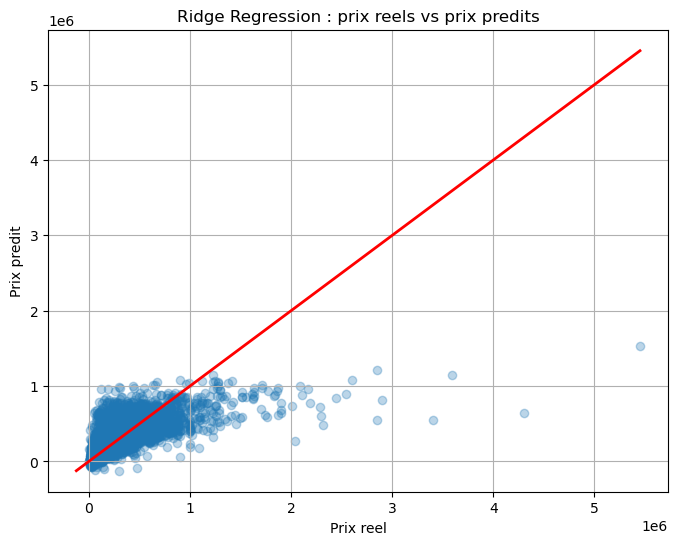


Top 10 des variables les plus influentes selon Ridge :


,Variable,Coefficient,Coefficient_abs
11,commune_prix_m2,157570.119158,157570.119158
0,surface_reelle_bati,144862.864316,144862.864316
8,is_maison,43052.554183,43052.554183
1,nombre_pieces_principales,-31738.539518,31738.539518
2,surface_terrain,-23202.120298,23202.120298
7,latitude,-17649.095789,17649.095789
5,code_departement,-12819.078396,12819.078396
9,is_neuf,12308.008836,12308.008836
12,commune_volume,5245.708066,5245.708066
10,anciennete_mois,-3057.178528,3057.178528


C:\Users\a\AppData\Local\Temp\ipykernel_2228\3697018715.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


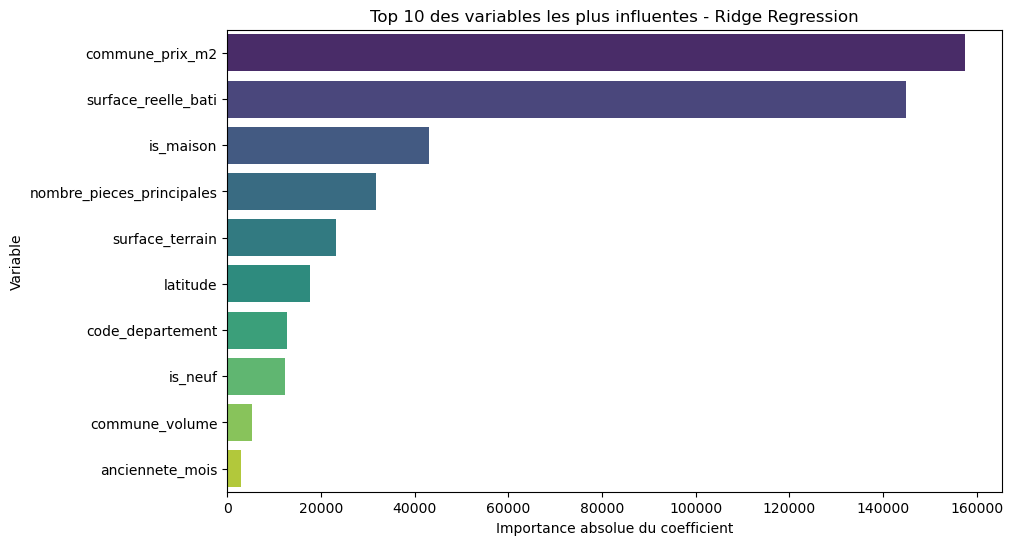


INTERPRETATION
- Ridge Regression est un modele lineaire regularise.
- Il sert de baseline simple pour comparer avec les modeles plus complexes.
- Les variables sont standardisees car elles ont des echelles tres differentes.
- Si le score est plus faible que Random Forest ou XGBoost, cela indique que la relation entre les variables et le prix n'est pas uniquement lineaire.


In [1]:
# ============================================================
# RIDGE REGRESSION - MODELISATION DU PRIX IMMOBILIER
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("=" * 60)
print("RIDGE REGRESSION - CHARGEMENT DES DONNEES")
print("=" * 60)

start_time = time.time()

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

load_time = time.time() - start_time

print("Chargement termine.")
print(f"Temps de chargement : {load_time:.2f} secondes")
print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test  : {X_test.shape}")
print(f"Dimensions y_train : {y_train.shape}")
print(f"Dimensions y_test  : {y_test.shape}")

print("\nApercu des variables explicatives :")
display(X_train.head())

print("\nValeurs manquantes dans X_train :")
display(X_train.isna().sum())

# ------------------------------------------------------------
# Creation du modele
# ------------------------------------------------------------
# Ridge est un modele lineaire regularise.
# StandardScaler est necessaire car les variables n'ont pas les memes echelles.

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

print("\nModele Ridge cree :")
print(ridge_model)

# ------------------------------------------------------------
# Entrainement
# ------------------------------------------------------------

print("\nDebut de l'entrainement Ridge Regression...")
start_train = time.time()

ridge_model.fit(X_train, y_train)

train_time = time.time() - start_train
print(f"Entrainement termine en {train_time:.2f} secondes.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

print("\nPredictions sur le jeu de test...")
start_pred = time.time()

y_pred_ridge = ridge_model.predict(X_test)

pred_time = time.time() - start_pred
print(f"Predictions terminees en {pred_time:.2f} secondes.")

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

mask = y_test != 0
mape_ridge = np.mean(np.abs((y_test[mask] - y_pred_ridge[mask]) / y_test[mask])) * 100

print("\n" + "=" * 60)
print("RESULTATS DU MODELE : RIDGE REGRESSION")
print("=" * 60)
print(f"R2 Score                  : {r2_ridge:.4f}")
print(f"MAE - Erreur moyenne      : {mae_ridge:,.2f} euros")
print(f"RMSE - Erreur quadratique : {rmse_ridge:,.2f} euros")
print(f"MAPE - Erreur en %        : {mape_ridge:.2f} %")
print(f"Temps d'entrainement      : {train_time:.2f} secondes")
print(f"Temps de prediction       : {pred_time:.2f} secondes")
print("=" * 60)

# ------------------------------------------------------------
# Graphique prix reels vs prix predits
# ------------------------------------------------------------

sample_size = 10000
y_test_sample = y_test[:sample_size]
y_pred_sample = y_pred_ridge[:sample_size]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample, alpha=0.3)

min_val = min(y_test_sample.min(), y_pred_sample.min())
max_val = max(y_test_sample.max(), y_pred_sample.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2)

plt.title("Ridge Regression : prix reels vs prix predits")
plt.xlabel("Prix reel")
plt.ylabel("Prix predit")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Analyse des coefficients
# ------------------------------------------------------------

ridge_coefficients = ridge_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": ridge_coefficients
})

coef_df["Coefficient_abs"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Coefficient_abs", ascending=False)

print("\nTop 10 des variables les plus influentes selon Ridge :")
display(coef_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df.head(10),
    x="Coefficient_abs",
    y="Variable",
    palette="viridis"
)
plt.title("Top 10 des variables les plus influentes - Ridge Regression")
plt.xlabel("Importance absolue du coefficient")
plt.ylabel("Variable")
plt.show()

# ------------------------------------------------------------
# Interpretation synthetique
# ------------------------------------------------------------

print("\nINTERPRETATION")
print("- Ridge Regression est un modele lineaire regularise.")
print("- Il sert de baseline simple pour comparer avec les modeles plus complexes.")
print("- Les variables sont standardisees car elles ont des echelles tres differentes.")
print("- Si le score est plus faible que Random Forest ou XGBoost, cela indique que la relation entre les variables et le prix n'est pas uniquement lineaire.")
